In [ ]:
from gettext import install

import pip
import wordcloud


pip install wordcloud


Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Cấu hình hiển thị
plt.style.use('ggplot')
sns.set(font_scale=1.2)
%matplotlib inline

print(" Import thư viện thành công. ")

 Import thư viện thành công. 


In [2]:
# Đọc file dữ liệu 
try:
    df = pd.read_csv('../datasets/raw/symptoms2.csv') # Hoặc 'symptoms.csv'
    print("Đã đọc file 'symptoms2.csv' thành công")
except:
    df = pd.read_csv('../datasets/raw/symptoms.csv')
    print("Đang dùng file gốc 'symptoms.csv'")

# Hiển thị 5 dòng đầu
display(df.head())

# Kiểm tra thông tin tổng quát
print("\n--- THÔNG TIN DỮ LIỆU ---")
print(df.info())

# Kiểm tra dữ liệu trùng lặp
print(f"\nSố lượng dòng trùng lặp: {df.duplicated().sum()}")

Đã đọc file 'symptoms2.csv' thành công


,text,outcome,stage
0,Tôi bị khát nước và đi tiểu thường xuyên. Tôi ...,1,1
1,Cơ thể tôi run rẩy. Khứu giác và vị giác yếu đ...,1,2
2,"hay thấy ngứa ran ở lòng bàn chân, bàn tay",1,3
3,"tôi thấy nước tiểu có màu hơi hồng, giống như ...",0,0
4,tôi thấy kiến bu quanh nước tiểu của mình ở nh...,1,2



--- THÔNG TIN DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     367 non-null    object
 1   outcome  367 non-null    int64 
 2   stage    367 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 8.7+ KB
None

Số lượng dòng trùng lặp: 0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17820\1479525689.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='outcome', data=df, palette='viridis')


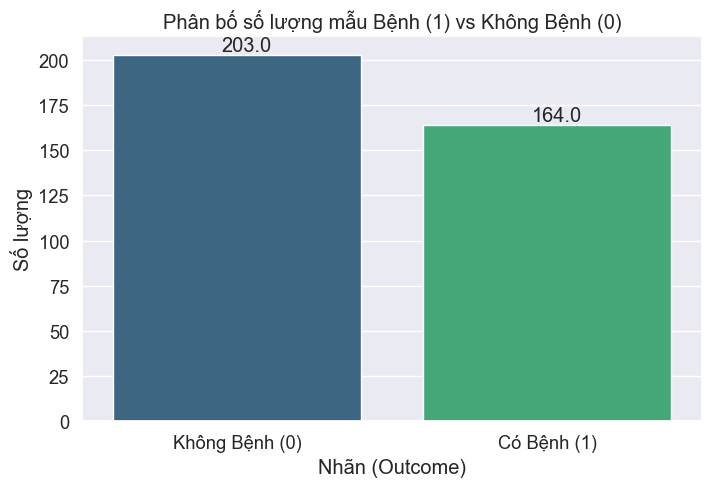

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='outcome', data=df, palette='viridis')

plt.title('Phân bố số lượng mẫu Bệnh (1) vs Không Bệnh (0)')
plt.xlabel('Nhãn (Outcome)')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không Bệnh (0)', 'Có Bệnh (1)'])

# Hiển thị số lượng trên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.35, p.get_height() + 2))

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17820\2405869628.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stage', data=df, palette='magma')


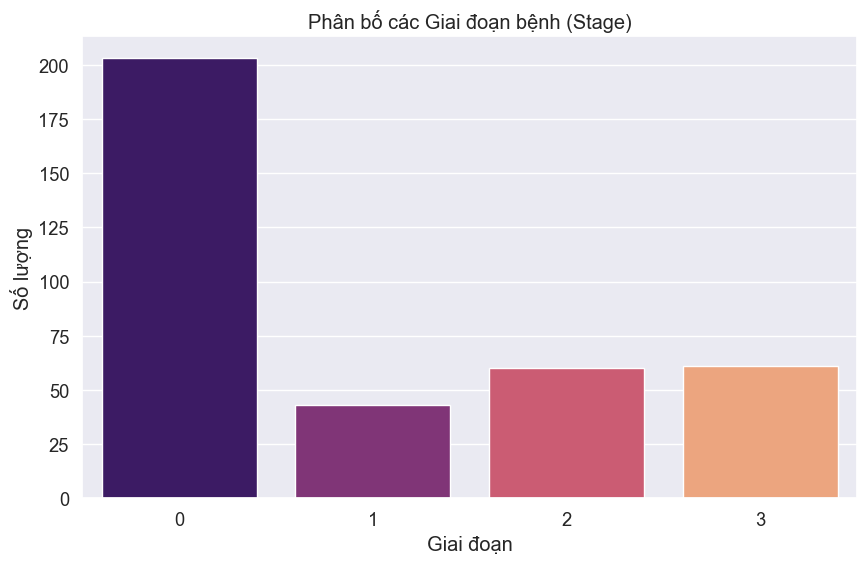

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(x='stage', data=df, palette='magma')

plt.title('Phân bố các Giai đoạn bệnh (Stage)')
plt.xlabel('Giai đoạn')
plt.ylabel('Số lượng')
plt.show()

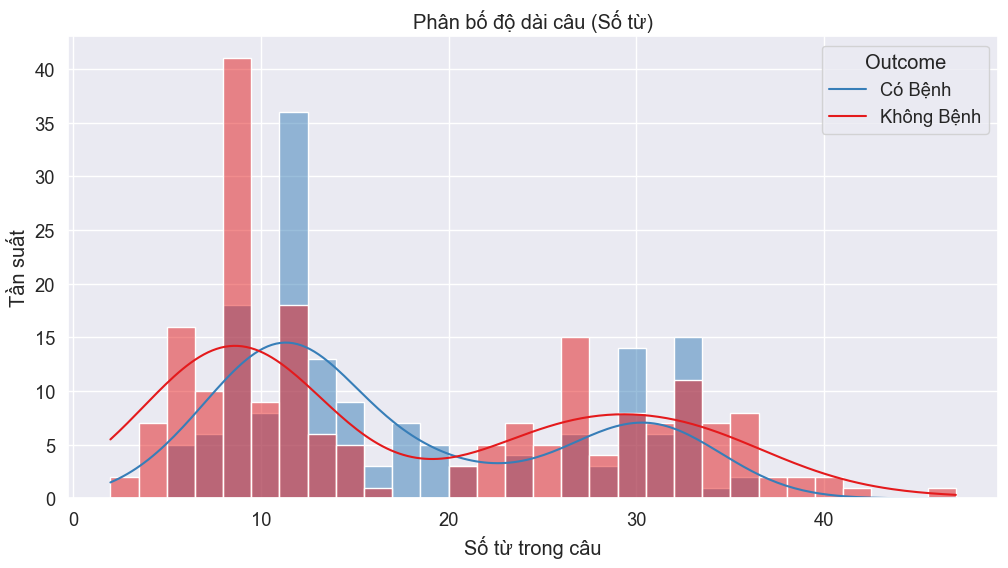

Độ dài trung bình: 17.69 từ
Độ dài lớn nhất: 47 từ


In [5]:
# Tính số từ trong mỗi câu
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='word_count', hue='outcome', kde=True, bins=30, palette='Set1')

plt.title('Phân bố độ dài câu (Số từ)')
plt.xlabel('Số từ trong câu')
plt.ylabel('Tần suất')
plt.legend(title='Outcome', labels=['Có Bệnh', 'Không Bệnh'])
plt.show()

print(f"Độ dài trung bình: {df['word_count'].mean():.2f} từ")
print(f"Độ dài lớn nhất: {df['word_count'].max()} từ")

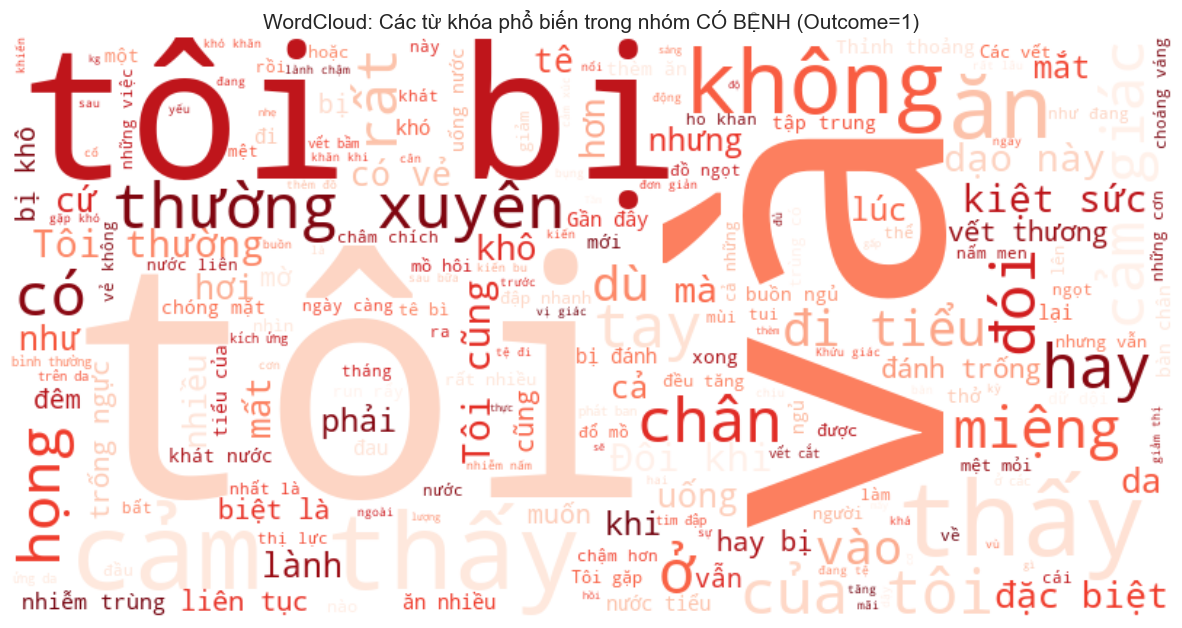

In [6]:
# Lọc các câu của người có bệnh (Outcome = 1)
sick_text = " ".join(text for text in df[df['outcome'] == 1]['text'])

# Tạo WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(sick_text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: Các từ khóa phổ biến trong nhóm CÓ BỆNH (Outcome=1)', fontsize=15)
plt.show()

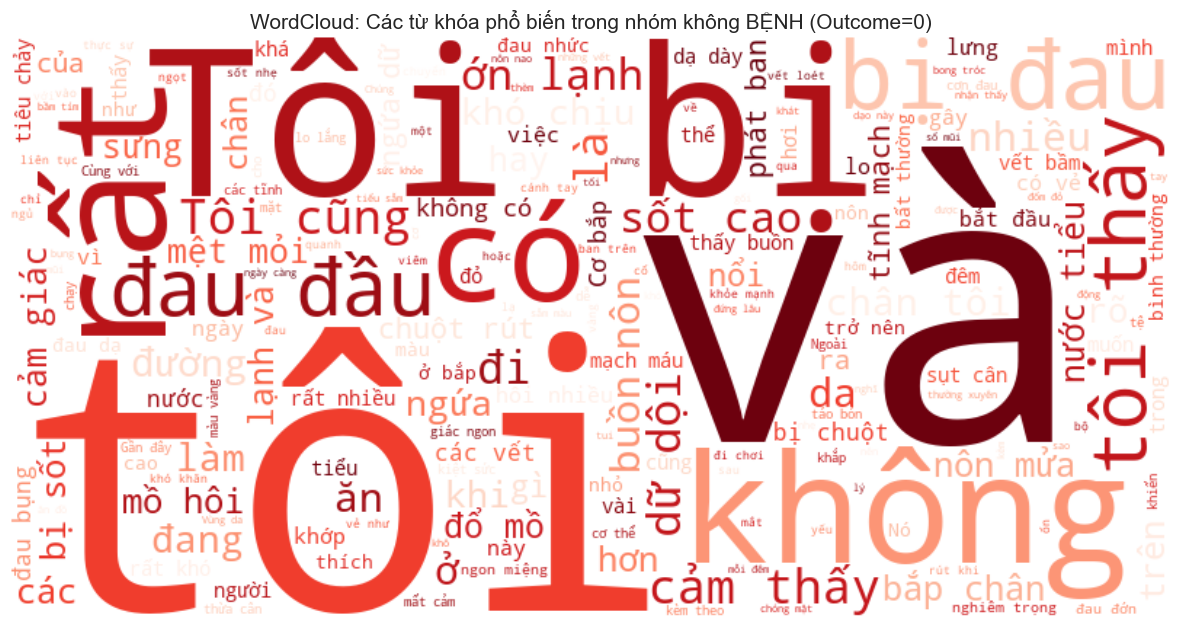

In [ ]:
# Lọc các câu của người không bệnh (Outcome = 0)
no_sick_text = " ".join(text for text in df[df['outcome'] == 0]['text'])

# Tạo WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(no_sick_text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: Các từ khóa phổ biến trong nhóm không BỆNH (Outcome=0)', fontsize=15)
plt.show()